### Imports

In [1]:
!pip install kaggle

In [2]:
import os
import random
import itertools
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

### Configuration and Load Data

In [3]:
os.system("kaggle datasets download -d jessicali9530/lfw-dataset")
os.system("unzip lfw-dataset.zip")

256

In [4]:
root = Path("lfw-deepfunneled")

for p in root.iterdir():
    print(p)

lfw-deepfunneled/lfw-deepfunneled


In [5]:
LFW_ROOT = Path("lfw-deepfunneled/lfw-deepfunneled")

In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [73]:
IMG_SIZE   = (64, 64)
CHANNELS   = 3
EMBED_DIM  = 128

BATCH_SIZE = 32
EPOCHS     = 25
LR         = 1e-4

MIN_IMAGES_PER_PERSON = 2   # only keep people with at least this many images
LIVE_THRESHOLD = 0.5

In [13]:
# ── 2.1 Load Dataset ─────────────────────────────────────────────────────────

def load_lfw_dataset(root: Path, min_images: int = MIN_IMAGES_PER_PERSON):
    dataset = {}
    for person_dir in sorted(root.iterdir()):
        if not person_dir.is_dir():
            continue
        images = sorted(person_dir.glob("*.jpg"))
        if len(images) >= min_images:
            dataset[person_dir.name] = images

    n_people = len(dataset)
    n_images = sum(len(v) for v in dataset.values())
    print(f"✓ Loaded {n_people} people | {n_images} total images")
    return dataset


def load_image(path: Path) -> np.ndarray:
    """Read an image, resize to IMG_SIZE, normalise to [0, 1]."""
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    return img.astype(np.float32) / 255.0


In [15]:
# ── 2.2 Create Pairs for Contrastive Loss ────────────────────────────────────

def create_pairs(dataset: dict, max_pairs_per_person: int = 10):
    people = list(dataset.keys())
    pairs_A, pairs_B, labels = [], [], []

    # ── Positive pairs ────────────────────────────────────────────────────────
    for person, imgs in dataset.items():
        combos = list(itertools.combinations(imgs, 2))
        random.shuffle(combos)
        for img_a_path, img_b_path in combos[:max_pairs_per_person]:
            pairs_A.append(load_image(img_a_path))
            pairs_B.append(load_image(img_b_path))
            labels.append(1)

    n_positive = len(labels)

    # ── Negative pairs (same count as positive) ───────────────────────────────
    while len(labels) < 2 * n_positive:
        p1, p2 = random.sample(people, 2)
        img_a_path = random.choice(dataset[p1])
        img_b_path = random.choice(dataset[p2])
        pairs_A.append(load_image(img_a_path))
        pairs_B.append(load_image(img_b_path))
        labels.append(0)

    # ── Shuffle and convert to numpy ─────────────────────────────────────────
    combined = list(zip(pairs_A, pairs_B, labels))
    random.shuffle(combined)
    pairs_A, pairs_B, labels = zip(*combined)

    print(f"✓ Pairs created: {n_positive} positive | {n_positive} negative | "
          f"{2 * n_positive} total")

    return (np.array(pairs_A, dtype=np.float32),
            np.array(pairs_B, dtype=np.float32),
            np.array(labels,  dtype=np.float32))


In [18]:
# ── 2.3 Create Triplets for Triplet Loss ─────────────────────────────────────

def create_triplets(dataset: dict, n_triplets: int = 5000):

    people = list(dataset.keys())
    # Only people with >= 2 images can serve as anchor/positive sources
    eligible = [p for p in people if len(dataset[p]) >= 2]

    anchors, positives, negatives = [], [], []

    for _ in range(n_triplets):
        # Pick anchor person (must have ≥ 2 images)
        anchor_person = random.choice(eligible)
        imgs = dataset[anchor_person]

        # Sample two DIFFERENT images from anchor person
        anchor_path, positive_path = random.sample(imgs, 2)

        # Pick a negative person (different from anchor)
        negative_person = random.choice([p for p in people if p != anchor_person])
        negative_path   = random.choice(dataset[negative_person])

        anchors.append(load_image(anchor_path))
        positives.append(load_image(positive_path))
        negatives.append(load_image(negative_path))

    print(f"✓ Triplets created: {n_triplets} triplets")

    return (np.array(anchors,   dtype=np.float32),
            np.array(positives, dtype=np.float32),
            np.array(negatives, dtype=np.float32))


In [19]:
# ── 2.4 Build tf.data Pipelines ──────────────────────────────────────────────

def make_pair_dataset(pairs_A, pairs_B, labels, batch_size=BATCH_SIZE):

    ds = tf.data.Dataset.from_tensor_slices(((pairs_A, pairs_B), labels))
    ds = ds.shuffle(buffer_size=1024, seed=SEED)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


def make_triplet_dataset(anchors, positives, negatives, batch_size=BATCH_SIZE):

    dummy_labels = np.zeros(len(anchors), dtype=np.float32)
    ds = tf.data.Dataset.from_tensor_slices(
        ((anchors, positives, negatives), dummy_labels)
    )
    ds = ds.shuffle(buffer_size=1024, seed=SEED)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


In [20]:
# ── Run Data Loading ──────────────────────────────────────────────────────────

print("\n" + "─" * 60)
print("STEP 2: Loading Dataset")
print("─" * 60)

dataset = load_lfw_dataset(LFW_ROOT)

# Create pairs (for Contrastive Loss models)
print("\nCreating pairs …")
pairs_A, pairs_B, pair_labels = create_pairs(dataset, max_pairs_per_person=5)

# Train / val split for pairs
(trA_p, vaA_p,
 trB_p, vaB_p,
 trL_p, vaL_p) = train_test_split(pairs_A, pairs_B, pair_labels,
                                   test_size=0.2, random_state=SEED,
                                   stratify=pair_labels)

train_pair_ds = make_pair_dataset(trA_p, trB_p, trL_p)
val_pair_ds   = make_pair_dataset(vaA_p, vaB_p, vaL_p)



────────────────────────────────────────────────────────────
STEP 2: Loading Dataset
────────────────────────────────────────────────────────────
✓ Loaded 1680 people | 9164 total images

Creating pairs …
✓ Pairs created: 4702 positive | 4702 negative | 9404 total


In [21]:
# Create triplets (for Triplet Loss models)
print("\nCreating triplets …")
anchors, positives, negatives = create_triplets(dataset, n_triplets=2000)

(tr_anc, va_anc,
 tr_pos, va_pos,
 tr_neg, va_neg) = train_test_split(anchors, positives, negatives,
                                    test_size=0.2, random_state=SEED)

train_trip_ds = make_triplet_dataset(tr_anc, tr_pos, tr_neg)
val_trip_ds   = make_triplet_dataset(va_anc, va_pos, va_neg)

print(f"\n  Train pairs : {len(trA_p):,}  |  Val pairs : {len(vaA_p):,}")
print(f"  Train trips : {len(tr_anc):,}  |  Val trips : {len(va_anc):,}")



Creating triplets …
✓ Triplets created: 2000 triplets

  Train pairs : 7,523  |  Val pairs : 1,881
  Train trips : 1,600  |  Val trips : 400


## Build Models

### CNN

In [22]:
# ── 3.1 Custom CNN Backbone ───────────────────────────────────────────────────

def build_custom_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS),
                     embed_dim=EMBED_DIM,
                     name="custom_cnn"):

    inp = Input(shape=input_shape, name="image_input")

    # Block 1
    x = layers.Conv2D(32, 3, activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 2
    x = layers.Conv2D(64, 3, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 3
    x = layers.Conv2D(128, 3, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)

    # Embedding head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(embed_dim)(x)

    # L2 normalisation — keeps embeddings on the unit hypersphere
    embeddings = layers.Lambda(
        lambda t: tf.math.l2_normalize(t, axis=1),
        name="l2_norm"
    )(x)

    return Model(inputs=inp, outputs=embeddings, name=name)


### VGG16

In [23]:
# ── 3.2 VGG16 Transfer Learning Backbone ─────────────────────────────────────

def build_vgg16_backbone(input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS),
                         embed_dim=EMBED_DIM,
                         name="vgg16_backbone"):

    inp = Input(shape=input_shape, name="image_input")

    # VGG16 expects [0, 255]; our images are [0, 1], so rescale
    x_scaled = layers.Lambda(lambda t: t * 255.0)(inp)

    # Load VGG16 without its top FC layers
    vgg = VGG16(include_top=False,
                weights="imagenet",
                input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS))
    vgg.trainable = False   # freeze all VGG16 layers

    x = vgg(x_scaled, training=False)   # training=False → BN in inference mode

    # Embedding head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(embed_dim)(x)

    embeddings = layers.Lambda(
        lambda t: tf.math.l2_normalize(t, axis=1),
        name="l2_norm"
    )(x)

    return Model(inputs=inp, outputs=embeddings, name=name)


### Siamese Wrappers

In [24]:
# ── 3.3 Siamese Wrappers ──────────────────────────────────────────────────────

def build_siamese_pair_model(backbone: Model):

    img_a = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS), name="image_a")
    img_b = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS), name="image_b")

    emb_a = backbone(img_a)
    emb_b = backbone(img_b)

    return Model(inputs=[img_a, img_b],
                 outputs=[emb_a, emb_b],
                 name=f"siamese_pair_{backbone.name}")


def build_siamese_triplet_model(backbone: Model):

    anchor   = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS), name="anchor")
    positive = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS), name="positive")
    negative = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS), name="negative")

    emb_anc = backbone(anchor)
    emb_pos = backbone(positive)
    emb_neg = backbone(negative)

    return Model(inputs=[anchor, positive, negative],
                 outputs=[emb_anc, emb_pos, emb_neg],
                 name=f"siamese_triplet_{backbone.name}")


### Models summary

In [25]:
# ── Inspect the architectures

custom_backbone = build_custom_cnn()

custom_backbone.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_norm (Lambda)                │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,064 (625.25 KB)

 Trainable params: 159,616 (623.50 KB)

 Non-trainable params: 448 (1.75 KB)

In [26]:
vgg16_backbone  = build_vgg16_backbone()

vgg16_backbone.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "vgg16_backbone"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_norm (Lambda)                │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,878,912 (56.76 MB)

 Trainable params: 164,224 (641.50 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Loss Functions

In [27]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — Loss Functions
# ═══════════════════════════════════════════════════════════════════════════════
MARGIN_CONTRASTIVE = 1.0
MARGIN_TRIPLET     = 0.3

In [28]:

def contrastive_loss(y_true, embeddings, margin=MARGIN_CONTRASTIVE):

    emb_a, emb_b = embeddings

    # Euclidean distance between each pair of embeddings
    d = tf.reduce_sum(tf.square(emb_a - emb_b), axis=1)   # shape (B,)
    d = tf.sqrt(d + 1e-8)                                  # avoid sqrt(0) NaN

    # Contrastive loss components
    # y_true=1 → same person → pull together
    # y_true=0 → different   → push apart up to margin
    loss_same = y_true       * 0.5 * tf.square(d)
    loss_diff = (1 - y_true) * 0.5 * tf.square(tf.maximum(0.0, margin - d))

    return tf.reduce_mean(loss_same + loss_diff)


In [29]:
def triplet_loss(embeddings, margin=MARGIN_TRIPLET):

    emb_a, emb_p, emb_n = embeddings

    # Squared Euclidean distances
    d_ap = tf.reduce_sum(tf.square(emb_a - emb_p), axis=1)  # anchor-positive
    d_an = tf.reduce_sum(tf.square(emb_a - emb_n), axis=1)  # anchor-negative

    # Triplet loss: penalise when d_ap is NOT smaller than d_an by at least margin
    loss = tf.maximum(0.0, d_ap - d_an + margin)

    return tf.reduce_mean(loss)


In [74]:
def batch_contrastive_accuracy(y_true, ea, eb, threshold=LIVE_THRESHOLD):
    d     = tf.sqrt(tf.reduce_sum(tf.square(ea - eb), axis=1) + 1e-8)
    preds = tf.cast(d < threshold, tf.float32)   # 1=same, 0=different
    return tf.reduce_mean(tf.cast(tf.equal(preds, y_true), tf.float32))


def batch_triplet_accuracy(ea, ep, en):
    d_ap = tf.reduce_sum(tf.square(ea - ep), axis=1)
    d_an = tf.reduce_sum(tf.square(ea - en), axis=1)
    return tf.reduce_mean(tf.cast(d_ap < d_an, tf.float32))

### Training Step Wrappers

In [75]:
# ── 4.1 Custom Training Step Wrappers ─────────────────────────────────────────

class ContrastiveSiameseTrainer:

    def __init__(self, backbone: Model, lr: float = LR):
        self.backbone  = backbone
        self.model     = build_siamese_pair_model(backbone)
        self.optimizer = Adam(learning_rate=lr)

    @tf.function
    def train_step(self, batch):
        (ia, ib), y = batch
        y = tf.cast(y, tf.float32)
        with tf.GradientTape() as tape:
            ea, eb = self.model([ia, ib], training=True)
            loss   = contrastive_loss(y, (ea, eb))
        grads = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        acc = batch_contrastive_accuracy(y, ea, eb)
        return loss, acc

    @tf.function
    def val_step(self, batch):
        (ia, ib), y = batch
        y = tf.cast(y, tf.float32)
        ea, eb = self.model([ia, ib], training=False)
        loss   = contrastive_loss(y, (ea, eb))
        acc    = batch_contrastive_accuracy(y, ea, eb)
        return loss, acc

In [76]:
class TripletSiameseTrainer:

    def __init__(self, backbone: Model, lr: float = LR):
        self.backbone  = backbone
        self.model     = build_siamese_triplet_model(backbone)
        self.optimizer = Adam(learning_rate=lr)

    @tf.function
    def train_step(self, batch):
        (a, p, n), _ = batch
        with tf.GradientTape() as tape:
            ea, ep, en = self.model([a, p, n], training=True)
            loss       = triplet_loss((ea, ep, en))
        grads = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        acc = batch_triplet_accuracy(ea, ep, en)
        return loss, acc

    @tf.function
    def val_step(self, batch):
        (a, p, n), _ = batch
        ea, ep, en = self.model([a, p, n], training=False)
        loss = triplet_loss((ea, ep, en))
        acc  = batch_triplet_accuracy(ea, ep, en)
        return loss, acc

### Training Pipeline

In [78]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 5 — Training Pipeline
# ═══════════════════════════════════════════════════════════════════════════════

def run_training(trainer, train_ds, val_ds,
                 epochs=EPOCHS, patience=7, name="experiment"):

    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}
    best_val_loss = float("inf")
    wait = 0

    # ── Header ────────────────────────────────────────────────────────────────
    print(f"\n{'─'*74}")
    print(f"  Experiment : {name}")
    print(f"{'─'*74}")
    print(f"  {'Epoch':>6}  {'train_loss':>12}  {'val_loss':>10}  "
          f"{'train_acc':>10}  {'val_acc':>9}")
    print(f"{'─'*74}")

    for epoch in range(1, epochs + 1):

        # ── Train pass ────────────────────────────────────────────────────────
        tr_l, tr_a = [], []
        for batch in train_ds:
            loss, acc = trainer.train_step(batch)
            tr_l.append(float(loss)); tr_a.append(float(acc))
        tr_loss = float(np.mean(tr_l))
        tr_acc  = float(np.mean(tr_a))

        # ── Validation pass ───────────────────────────────────────────────────
        va_l, va_a = [], []
        for batch in val_ds:
            loss, acc = trainer.val_step(batch)
            va_l.append(float(loss)); va_a.append(float(acc))
        va_loss = float(np.mean(va_l))
        va_acc  = float(np.mean(va_a))

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        # ── Epoch log ─────────────────────────────────────────────────────────
        print(f"  {epoch:>6d}  {tr_loss:>12.4f}  {va_loss:>10.4f}  "
              f"{tr_acc:>10.4f}  {va_acc:>9.4f}")

        # ── Early stopping + checkpoint ───────────────────────────────────────
        if va_loss < best_val_loss - 1e-4:
            best_val_loss = va_loss
            wait = 0
            trainer.backbone.save_weights(f"best_{name}.weights.h5")
        else:
            wait += 1
            if wait >= patience:
                print(f"\n  ↳ Early stopping at epoch {epoch}. "
                      f"Best val_loss = {best_val_loss:.4f}")
                break

    print(f"{'─'*74}")
    return history

In [70]:
all_histories = {}

In [79]:
# ── Experiment 1: Custom CNN + Contrastive Loss ───────────────────────────────
print("\n[1/4] Custom CNN + Contrastive Loss")
cnn_contrastive_backbone = build_custom_cnn(name="cnn_contrastive")
exp1 = ContrastiveSiameseTrainer(cnn_contrastive_backbone)
all_histories["CNN + Contrastive"] = run_training(
    exp1, train_pair_ds, val_pair_ds, name="cnn_contrastive"
)



[1/4] Custom CNN + Contrastive Loss

──────────────────────────────────────────────────────────────────────────
  Experiment : cnn_contrastive
──────────────────────────────────────────────────────────────────────────
   Epoch    train_loss    val_loss   train_acc    val_acc
──────────────────────────────────────────────────────────────────────────
       1        0.1220      0.1286      0.5660     0.5299
       2        0.1189      0.1200      0.5907     0.5814
       3        0.1166      0.1186      0.6109     0.5861
       4        0.1146      0.1170      0.6179     0.5936
       5        0.1120      0.1137      0.6428     0.6147
       6        0.1101      0.1122      0.6530     0.6262
       7        0.1087      0.1085      0.6540     0.6410
       8        0.1061      0.1073      0.6660     0.6533
       9        0.1053      0.1053      0.6726     0.6694
      10        0.1036      0.1039      0.6780     0.6790
      11        0.1022      0.1023      0.6804     0.6840
      12  

In [80]:
# ── Experiment 2: Custom CNN + Triplet Loss ────────────────────────────────────
print("\n[2/4] Custom CNN + Triplet Loss")
cnn_triplet_backbone = build_custom_cnn(name="cnn_triplet")
exp2 = TripletSiameseTrainer(cnn_triplet_backbone)
all_histories["CNN + Triplet"] = run_training(
    exp2, train_trip_ds, val_trip_ds, name="cnn_triplet"
)


[2/4] Custom CNN + Triplet Loss

──────────────────────────────────────────────────────────────────────────
  Experiment : cnn_triplet
──────────────────────────────────────────────────────────────────────────
   Epoch    train_loss    val_loss   train_acc    val_acc
──────────────────────────────────────────────────────────────────────────
       1        0.2680      0.2974      0.5981     0.5697
       2        0.2526      0.2912      0.6175     0.5697
       3        0.2411      0.2722      0.6394     0.5962
       4        0.2301      0.2562      0.6600     0.6058
       5        0.2212      0.2431      0.6837     0.6514
       6        0.2095      0.2360      0.6981     0.6538
       7        0.2087      0.2371      0.7000     0.6635
       8        0.2023      0.2353      0.7094     0.6707
       9        0.1976      0.2279      0.7087     0.6755
      10        0.1862      0.2198      0.7338     0.6683
      11        0.1805      0.2242      0.7362     0.6875
      12        0.

In [81]:
# ── Experiment 3: VGG16 + Contrastive Loss ────────────────────────────────────
print("\n[3/4] VGG16 + Contrastive Loss")
vgg_contrastive_backbone = build_vgg16_backbone(name="vgg16_contrastive")
exp3 = ContrastiveSiameseTrainer(vgg_contrastive_backbone)
all_histories["VGG16 + Contrastive"] = run_training(
    exp3, train_pair_ds, val_pair_ds, name="vgg16_contrastive"
)


[3/4] VGG16 + Contrastive Loss

──────────────────────────────────────────────────────────────────────────
  Experiment : vgg16_contrastive
──────────────────────────────────────────────────────────────────────────
   Epoch    train_loss    val_loss   train_acc    val_acc
──────────────────────────────────────────────────────────────────────────
       1        0.1198      0.1131      0.6078     0.6337
       2        0.1083      0.1096      0.6668     0.6411
       3        0.1030      0.1076      0.7014     0.6472
       4        0.0993      0.1061      0.7164     0.6544
       5        0.0964      0.1048      0.7323     0.6569
       6        0.0938      0.1040      0.7481     0.6664
       7        0.0916      0.1032      0.7555     0.6712
       8        0.0892      0.1026      0.7697     0.6771
       9        0.0873      0.1023      0.7810     0.6767
      10        0.0856      0.1020      0.7899     0.6765
      11        0.0837      0.1017      0.7999     0.6757
      12     

In [82]:
# ── Experiment 4: VGG16 + Triplet Loss ────────────────────────────────────────
print("\n[4/4] VGG16 + Triplet Loss")
vgg_triplet_backbone = build_vgg16_backbone(name="vgg16_triplet")
exp4 = TripletSiameseTrainer(vgg_triplet_backbone)
all_histories["VGG16 + Triplet"] = run_training(
    exp4, train_trip_ds, val_trip_ds, name="vgg16_triplet"
)


[4/4] VGG16 + Triplet Loss

──────────────────────────────────────────────────────────────────────────
  Experiment : vgg16_triplet
──────────────────────────────────────────────────────────────────────────
   Epoch    train_loss    val_loss   train_acc    val_acc
──────────────────────────────────────────────────────────────────────────
       1        0.2229      0.2068      0.6700     0.6827
       2        0.1804      0.1947      0.7400     0.7019
       3        0.1458      0.1793      0.7937     0.7404
       4        0.1165      0.1742      0.8344     0.7548
       5        0.0925      0.1692      0.8731     0.7716
       6        0.0713      0.1669      0.9062     0.7644
       7        0.0542      0.1602      0.9325     0.7692
       8        0.0397      0.1629      0.9525     0.7668
       9        0.0279      0.1571      0.9675     0.7788
      10        0.0187      0.1577      0.9781     0.7740
      11        0.0123      0.1557      0.9906     0.7885
      12        0.007

## Evaluation & Visualization

In [83]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 6 — Evaluation & Visualization
# ═══════════════════════════════════════════════════════════════════════════════
COLORS = {
    "CNN + Contrastive" : ("#3B82F6", "#1D4ED8"),
    "CNN + Triplet"     : ("#10B981", "#065F46"),
    "VGG16 + Contrastive": ("#F59E0B", "#92400E"),
    "VGG16 + Triplet"   : ("#EF4444", "#991B1B"),
}

In [84]:
# ── 6.1 Loss Curves ──────────────────────────────────────────────────────────

def plot_loss_curves(histories: dict):
    """2×2 grid — train vs val LOSS for each experiment."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Training & Validation — Loss Curves",
                 fontsize=17, fontweight="bold", y=1.01)
    axes = axes.flatten()

    for ax, (name, hist) in zip(axes, histories.items()):
        ct, cv = COLORS[name]
        ep = range(1, len(hist["train_loss"]) + 1)

        ax.plot(ep, hist["train_loss"], color=ct, lw=2.2, label="Train loss")
        ax.plot(ep, hist["val_loss"],   color=cv, lw=2.2,
                linestyle="--", label="Val loss")

        best_ep  = int(np.argmin(hist["val_loss"])) + 1
        best_val = min(hist["val_loss"])
        ax.axvline(best_ep, color="grey", linestyle=":", lw=1.3,
                   label=f"Best ep={best_ep}  ({best_val:.4f})")

        ax.set_title(name, fontsize=13, fontweight="bold")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
        ax.legend(fontsize=9); ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig("loss_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ Saved → loss_curves.png")

In [85]:
# ── 6.2 Accuracy Curves ───────────────────────────────────────────────────────

def plot_accuracy_curves(histories: dict):

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Training & Validation — Accuracy Curves",
                 fontsize=17, fontweight="bold", y=1.01)
    axes = axes.flatten()

    for ax, (name, hist) in zip(axes, histories.items()):
        ct, cv = COLORS[name]
        ep = range(1, len(hist["train_acc"]) + 1)

        ax.plot(ep, hist["train_acc"], color=ct, lw=2.2, label="Train acc")
        ax.plot(ep, hist["val_acc"],   color=cv, lw=2.2,
                linestyle="--", label="Val acc")

        best_ep  = int(np.argmax(hist["val_acc"])) + 1
        best_val = max(hist["val_acc"])
        ax.axvline(best_ep, color="grey", linestyle=":", lw=1.3,
                   label=f"Best ep={best_ep}  ({best_val:.4f})")

        # 0.5 baseline — random chance for triplet ordering accuracy
        ax.axhline(0.5, color="black", linestyle="--", lw=0.9, alpha=0.35,
                   label="0.50 baseline")

        ax.set_title(name, fontsize=13, fontweight="bold")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
        ax.set_ylim(0.0, 1.05)
        ax.legend(fontsize=9); ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig("accuracy_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ Saved → accuracy_curves.png")


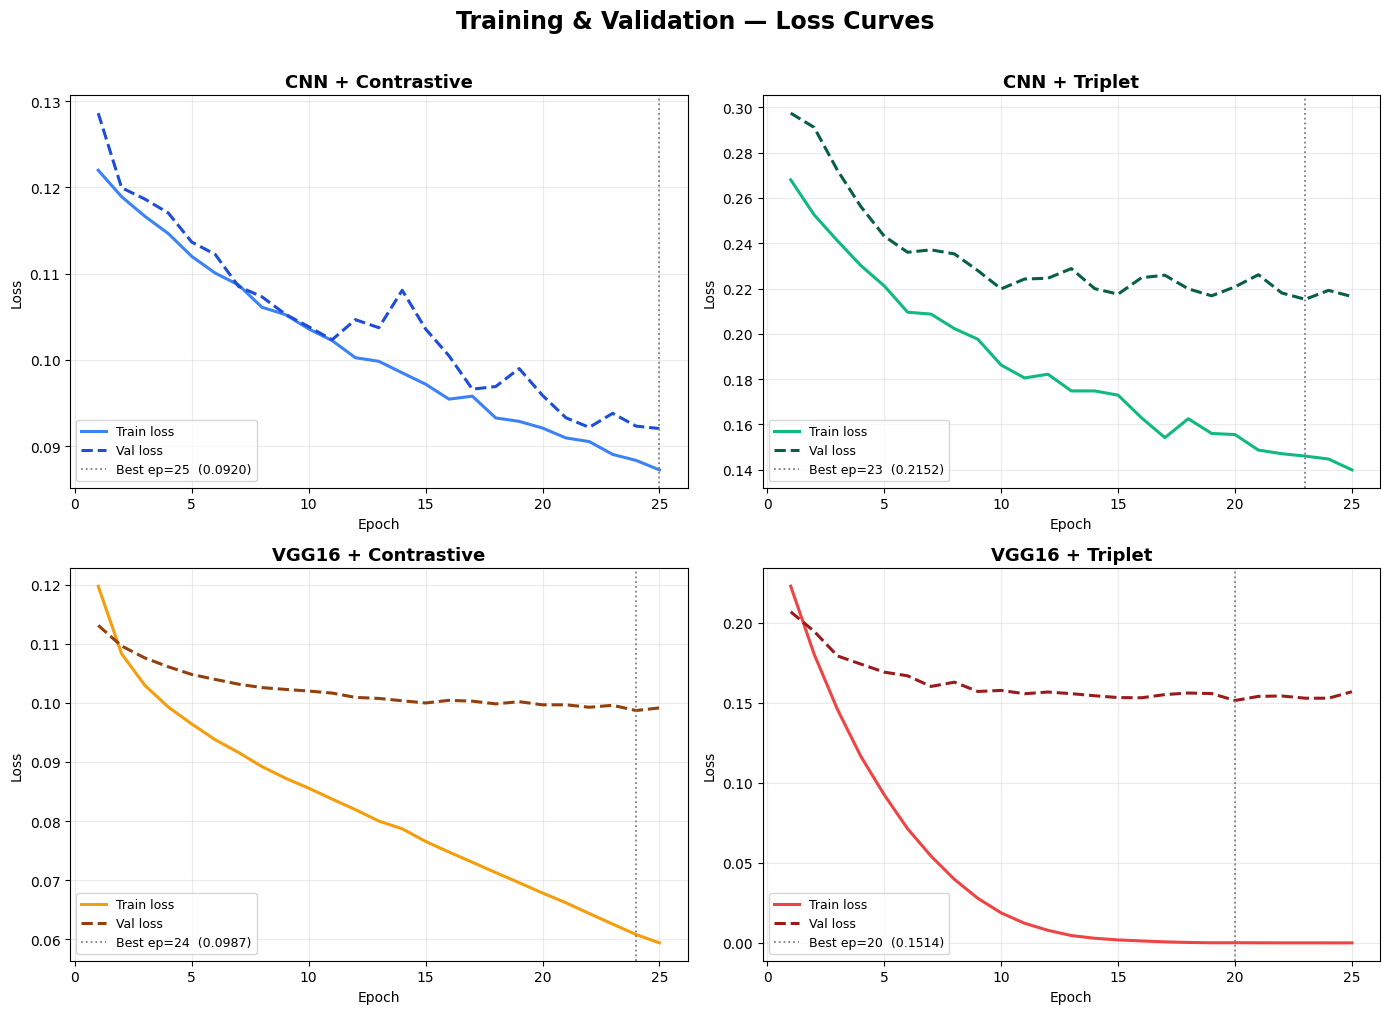

✓ Saved → loss_curves.png


In [88]:
# ── Run the three curve plots ─────────────────────────────────────────────────
plot_loss_curves(all_histories)

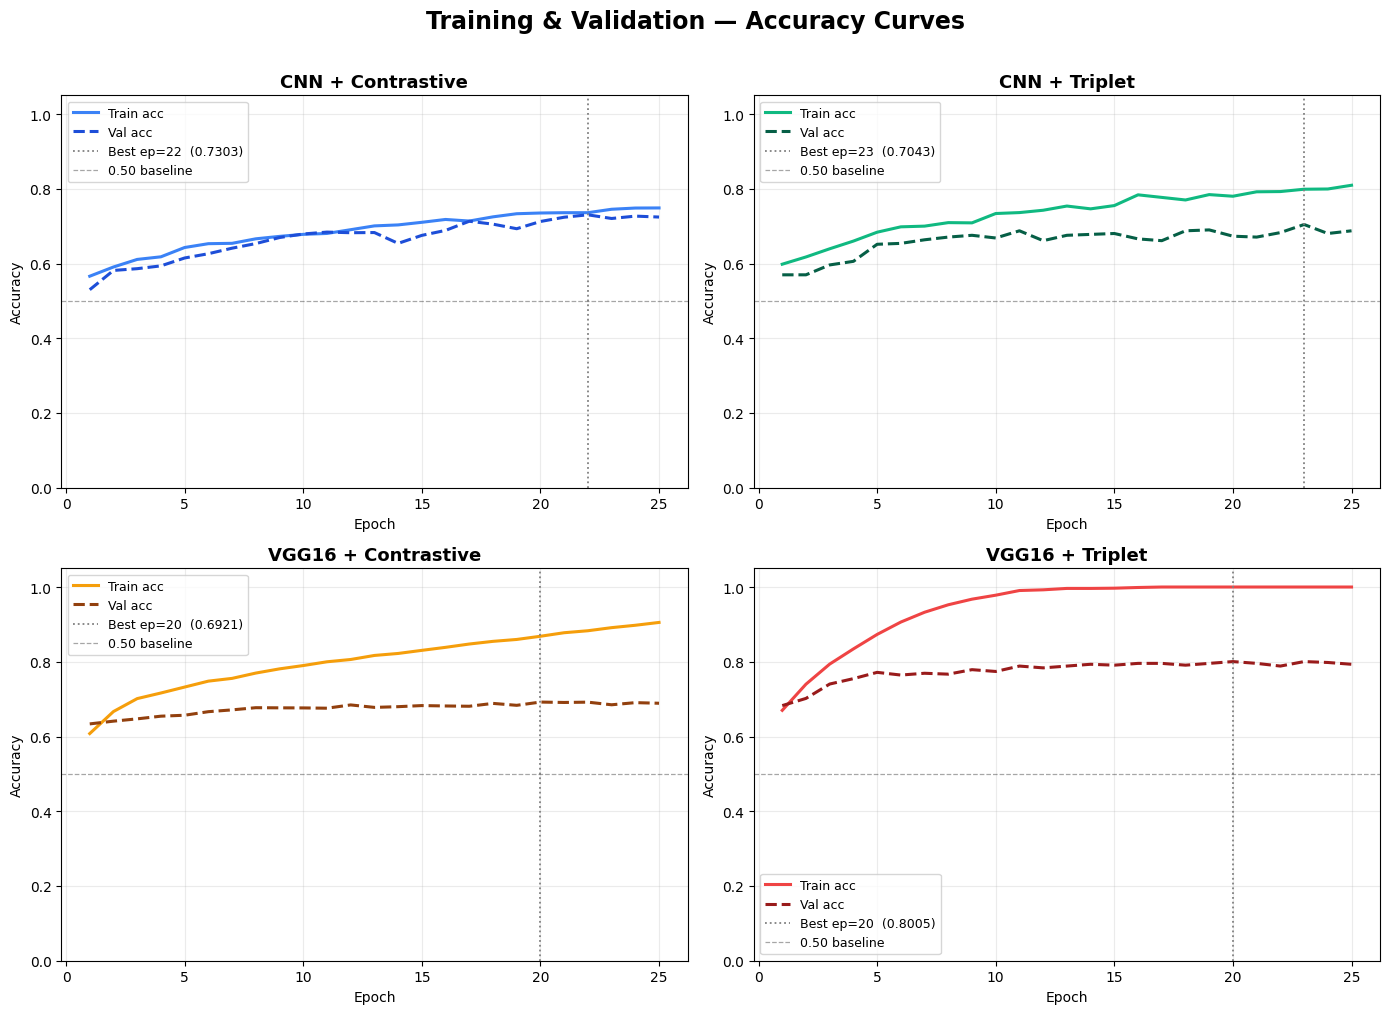

✓ Saved → accuracy_curves.png


In [89]:
plot_accuracy_curves(all_histories)


In [91]:
# ── 6.4 Distance Distribution Plots ──────────────────────────────────────────

def compute_pair_distances(backbone, pA, pB, labels, batch_size=64):
    """Return (pos_distances, neg_distances) for the full validation set."""
    pos_d, neg_d = [], []
    for i in range(0, len(pA), batch_size):
        ea = backbone(pA[i:i+batch_size], training=False).numpy()
        eb = backbone(pB[i:i+batch_size], training=False).numpy()
        d  = np.sqrt(np.sum((ea - eb) ** 2, axis=1))
        lb = labels[i:i+batch_size]
        pos_d.extend(d[lb == 1].tolist())
        neg_d.extend(d[lb == 0].tolist())
    return np.array(pos_d), np.array(neg_d)


In [93]:
def plot_distance_distributions(experiments: list):

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Distance Distribution: Positive vs Negative Pairs",
                 fontsize=17, fontweight="bold", y=1.01)
    axes = axes.flatten()

    for ax, (name, backbone, pA, pB, lbl) in zip(axes, experiments):
        pos_d, neg_d = compute_pair_distances(backbone, pA, pB, lbl)

        ax.hist(pos_d, bins=50, alpha=0.65, color="#3B82F6",
                label=f"Same person   μ={pos_d.mean():.3f}")
        ax.hist(neg_d, bins=50, alpha=0.65, color="#EF4444",
                label=f"Diff person   μ={neg_d.mean():.3f}")

        thresh = (pos_d.mean() + neg_d.mean()) / 2
        ax.axvline(thresh, color="black", linestyle=":", lw=1.8,
                   label=f"Midpoint ≈ {thresh:.3f}")

        ax.set_title(name, fontsize=13, fontweight="bold")
        ax.set_xlabel("Euclidean Distance"); ax.set_ylabel("Count")
        ax.legend(fontsize=9); ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig("distance_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ Saved → distance_distributions.png")


In [94]:
# Load best-checkpoint backbones for post-training evaluation
def load_best_backbone(builder, name, weights_file):
    bb = builder(name=name)
    try:
        bb.load_weights(weights_file)
        print(f"  ✓ Loaded: {weights_file}")
    except Exception as e:
        print(f"  ✗ Could not load {weights_file}: {e}")
    return bb

  ✓ Loaded: best_cnn_contrastive.weights.h5
  ✓ Loaded: best_cnn_triplet.weights.h5
  ✓ Loaded: best_vgg16_contrastive.weights.h5
  ✓ Loaded: best_vgg16_triplet.weights.h5


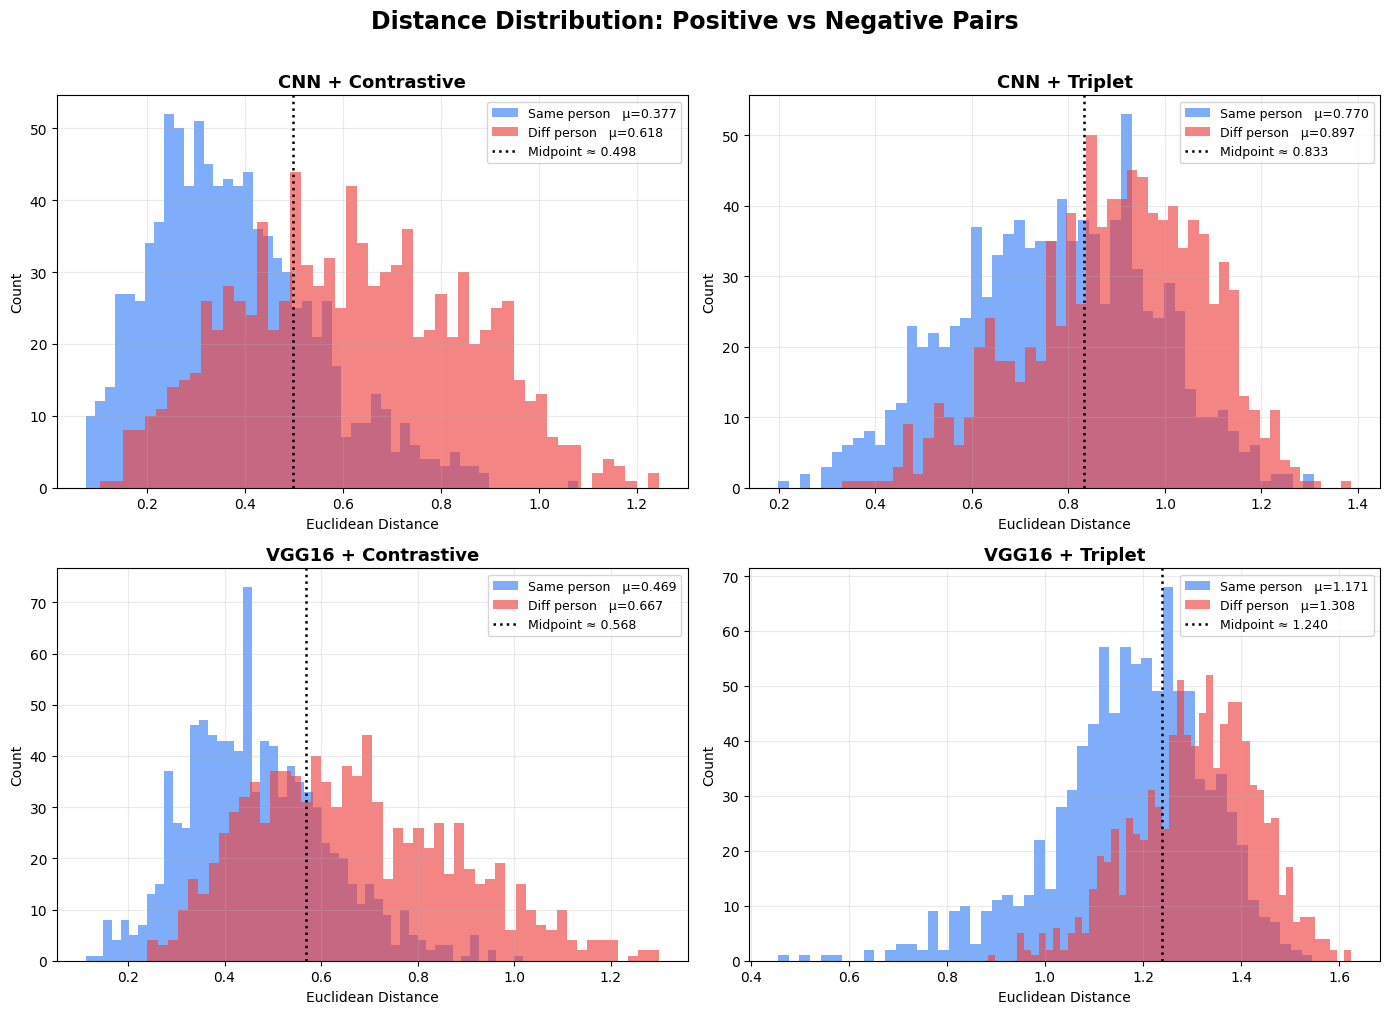

✓ Saved → distance_distributions.png


In [95]:
bb1 = load_best_backbone(build_custom_cnn,     "cnn_c_eval", "best_cnn_contrastive.weights.h5")
bb2 = load_best_backbone(build_custom_cnn,     "cnn_t_eval", "best_cnn_triplet.weights.h5")
bb3 = load_best_backbone(build_vgg16_backbone, "vgg_c_eval", "best_vgg16_contrastive.weights.h5")
bb4 = load_best_backbone(build_vgg16_backbone, "vgg_t_eval", "best_vgg16_triplet.weights.h5")

dist_experiments = [
    ("CNN + Contrastive",   bb1, vaA_p, vaB_p, vaL_p),
    ("CNN + Triplet",       bb2, vaA_p, vaB_p, vaL_p),
    ("VGG16 + Contrastive", bb3, vaA_p, vaB_p, vaL_p),
    ("VGG16 + Triplet",     bb4, vaA_p, vaB_p, vaL_p),
]

plot_distance_distributions(dist_experiments)


In [96]:
# ── 6.5 Calibrated Accuracy + Final Comparison Charts ────────────────────────

def accuracy_at_threshold(pos_d, neg_d, threshold):
    tp = np.sum(pos_d <  threshold)
    tn = np.sum(neg_d >= threshold)
    return (tp + tn) / (len(pos_d) + len(neg_d))


print("\n" + "─" * 70)
print("STEP 6.5: Best-Threshold Accuracy (sweep over validation set)")
print("─" * 70)

calibrated_results = {}
for name, backbone, pA, pB, lbl in dist_experiments:
    pos_d, neg_d  = compute_pair_distances(backbone, pA, pB, lbl)
    thresholds    = np.linspace(0, 2, 400)
    accs          = [accuracy_at_threshold(pos_d, neg_d, t) for t in thresholds]
    best_thresh   = thresholds[int(np.argmax(accs))]
    best_acc      = float(max(accs))
    calibrated_results[name] = {
        "calib_acc"    : best_acc,
        "threshold"    : best_thresh,
        "pos_mean"     : float(pos_d.mean()),
        "neg_mean"     : float(neg_d.mean()),
        "best_val_loss": float(min(all_histories[name]["val_loss"])),
        "best_val_acc" : float(max(all_histories[name]["val_acc"])),
    }
    print(f"  {name:25s} | calib_acc={best_acc:.3f} | thresh={best_thresh:.3f} | "
          f"μ_pos={pos_d.mean():.3f} | μ_neg={neg_d.mean():.3f}")



──────────────────────────────────────────────────────────────────────
STEP 6.5: Best-Threshold Accuracy (sweep over validation set)
──────────────────────────────────────────────────────────────────────
  CNN + Contrastive         | calib_acc=0.730 | thresh=0.491 | μ_pos=0.377 | μ_neg=0.618
  CNN + Triplet             | calib_acc=0.634 | thresh=0.832 | μ_pos=0.770 | μ_neg=0.897
  VGG16 + Contrastive       | calib_acc=0.704 | thresh=0.581 | μ_pos=0.469 | μ_neg=0.667
  VGG16 + Triplet           | calib_acc=0.692 | thresh=1.263 | μ_pos=1.171 | μ_neg=1.308


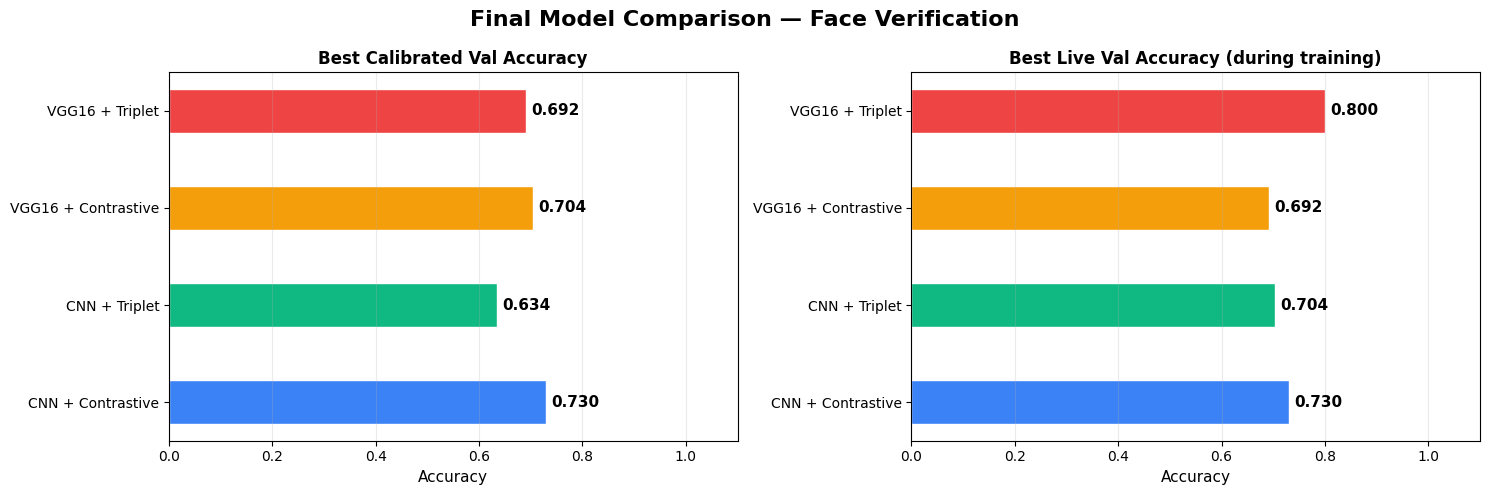

✓ Saved → model_comparison.png


In [97]:
# ── 6.4 Comparison Bar Chart ──────────────────────────────────────────────────

def plot_final_comparison(results: dict):
    """
    Two horizontal bar charts side by side:
      LEFT  — calibrated accuracy (best threshold on val set)
      RIGHT — live validation accuracy recorded during training
    """
    names     = list(results.keys())
    cal_accs  = [results[n]["calib_acc"]   for n in names]
    live_accs = [results[n]["best_val_acc"] for n in names]
    colors    = [COLORS[n][0]               for n in names]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle("Final Model Comparison — Face Verification",
                 fontsize=16, fontweight="bold")

    for ax, vals, title_label in [
        (ax1, cal_accs,  "Best Calibrated Val Accuracy"),
        (ax2, live_accs, "Best Live Val Accuracy (during training)"),
    ]:
        bars = ax.barh(names, vals, color=colors, edgecolor="white", height=0.45)
        ax.set_xlim(0, 1.10)
        ax.set_xlabel("Accuracy", fontsize=11)
        ax.set_title(title_label, fontsize=12, fontweight="bold")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_width() + 0.01,
                    bar.get_y() + bar.get_height() / 2,
                    f"{val:.3f}", va="center", fontsize=11, fontweight="bold")
        ax.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ Saved → model_comparison.png")


plot_final_comparison(calibrated_results)

In [98]:
# ── Full summary table ────────────────────────────────────────────────────────
print("\n" + "═" * 82)
print(f"  {'Model':25s} │ {'ValLoss':>9} │ {'LiveAcc':>8} │ "
      f"{'CalibAcc':>9} │ {'Threshold':>9} │ {'μ_pos':>6} │ {'μ_neg':>6}")
print("─" * 82)
for n, r in calibrated_results.items():
    print(f"  {n:25s} │ {r['best_val_loss']:>9.4f} │ {r['best_val_acc']:>8.4f} │ "
          f"{r['calib_acc']:>9.4f} │ {r['threshold']:>9.4f} │ "
          f"{r['pos_mean']:>6.3f} │ {r['neg_mean']:>6.3f}")
print("═" * 82)


══════════════════════════════════════════════════════════════════════════════════
  Model                     │   ValLoss │  LiveAcc │  CalibAcc │ Threshold │  μ_pos │  μ_neg
──────────────────────────────────────────────────────────────────────────────────
  CNN + Contrastive         │    0.0920 │   0.7303 │    0.7299 │    0.4912 │  0.377 │  0.618
  CNN + Triplet             │    0.2152 │   0.7043 │    0.6342 │    0.8321 │  0.770 │  0.897
  VGG16 + Contrastive       │    0.0987 │   0.6921 │    0.7044 │    0.5815 │  0.469 │  0.667
  VGG16 + Triplet           │    0.1514 │   0.8005 │    0.6917 │    1.2632 │  1.171 │  1.308
══════════════════════════════════════════════════════════════════════════════════


In [100]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 7 — Inference Function
# ═══════════════════════════════════════════════════════════════════════════════

def verify_faces(image_a, image_b, backbone: Model,
                 threshold: float = 0.5, show: bool = True):

    def _load(img):
        if isinstance(img, (str, Path)):
            return load_image(Path(img))
        return img.astype(np.float32)

    img_a = _load(image_a)
    img_b = _load(image_b)

    ea       = backbone(img_a[np.newaxis], training=False).numpy()[0]
    eb       = backbone(img_b[np.newaxis], training=False).numpy()[0]
    distance = float(np.sqrt(np.sum((ea - eb) ** 2)))
    same     = distance < threshold
    confidence = min(1.0, abs(distance - threshold) / (threshold + 1e-8))

    if show:
        verdict_color = "#22c55e" if same else "#ef4444"
        verdict_text  = "✅  SAME PERSON" if same else "❌  DIFFERENT PERSON"

        fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
        for ax, img, lbl in zip(axes, [img_a, img_b], ["Image A", "Image B"]):
            ax.imshow(np.clip(img, 0, 1))
            ax.set_title(lbl, fontsize=13, fontweight="bold")
            ax.axis("off")

        fig.suptitle(
            f"{verdict_text}\n"
            f"Distance = {distance:.4f}   │   Threshold = {threshold:.4f}"
            f"   │   Confidence = {confidence:.1%}",
            fontsize=12, fontweight="bold", color=verdict_color
        )
        plt.tight_layout()
        plt.savefig("inference_result.png", dpi=150, bbox_inches="tight")
        plt.show()

    print(f"\n{'─'*48}")
    print(f"  Euclidean distance : {distance:.4f}")
    print(f"  Threshold          : {threshold:.4f}")
    print(f"  Decision           : {'SAME PERSON ✅' if same else 'DIFFERENT PERSON ❌'}")
    print(f"  Confidence         : {confidence:.1%}")
    print(f"{'─'*48}\n")
    return {"distance": distance, "same_person": same, "confidence": confidence}


In [101]:
def demo_inference(backbone: Model, threshold: float, dataset: dict):
    """Two quick demos: one same-person pair, one different-person pair."""
    people = list(dataset.keys())

    # Same person
    person = random.choice([p for p in people if len(dataset[p]) >= 2])
    a, b   = random.sample(dataset[person], 2)
    print(f"\nDemo 1 — SAME PERSON  ({person})")
    verify_faces(a, b, backbone, threshold=threshold)

    # Different people
    p1, p2 = random.sample(people, 2)
    print(f"\nDemo 2 — DIFFERENT  ({p1}  vs  {p2})")
    verify_faces(random.choice(dataset[p1]),
                 random.choice(dataset[p2]),
                 backbone, threshold=threshold)



🏆 Best model : CNN + Contrastive  (calib. acc = 0.730, threshold = 0.491)

Demo 1 — SAME PERSON  (Jeb_Bush)


/tmp/ipykernel_30095/2042612396.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_30095/2042612396.py:39: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("inference_result.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


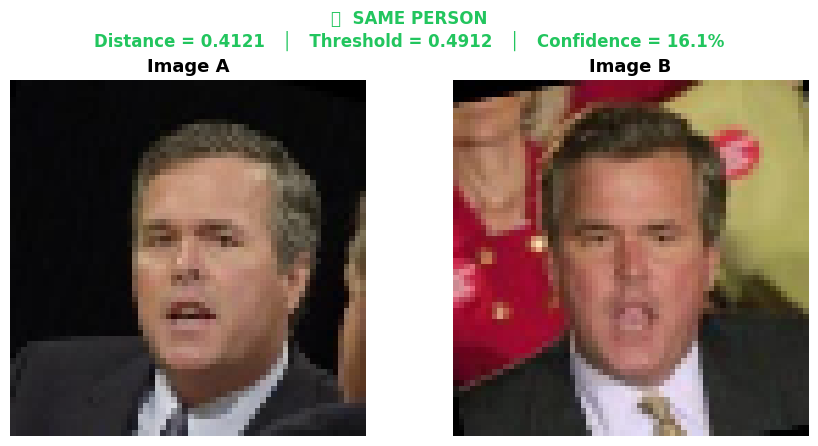

/tmp/ipykernel_30095/2042612396.py:38: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_30095/2042612396.py:39: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("inference_result.png", dpi=150, bbox_inches="tight")



────────────────────────────────────────────────
  Euclidean distance : 0.4121
  Threshold          : 0.4912
  Decision           : SAME PERSON ✅
  Confidence         : 16.1%
────────────────────────────────────────────────


Demo 2 — DIFFERENT  (Phil_Gramm  vs  Debra_Messing)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


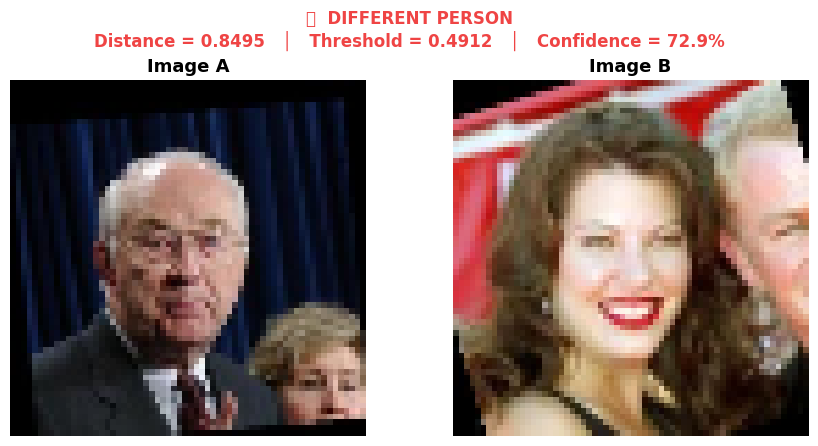


────────────────────────────────────────────────
  Euclidean distance : 0.8495
  Threshold          : 0.4912
  Decision           : DIFFERENT PERSON ❌
  Confidence         : 72.9%
────────────────────────────────────────────────



In [102]:
# Pick the best model overall
best_name = max(calibrated_results, key=lambda k: calibrated_results[k]["calib_acc"])
backbone_map = {
    "CNN + Contrastive":   bb1,
    "CNN + Triplet":       bb2,
    "VGG16 + Contrastive": bb3,
    "VGG16 + Triplet":     bb4,
}

best_backbone  = backbone_map[best_name]
best_threshold = calibrated_results[best_name]["threshold"]

print(f"\n🏆 Best model : {best_name}  "
      f"(calib. acc = {calibrated_results[best_name]['calib_acc']:.3f}, "
      f"threshold = {best_threshold:.3f})")

demo_inference(best_backbone, best_threshold, dataset)
